# 使用柔和配色

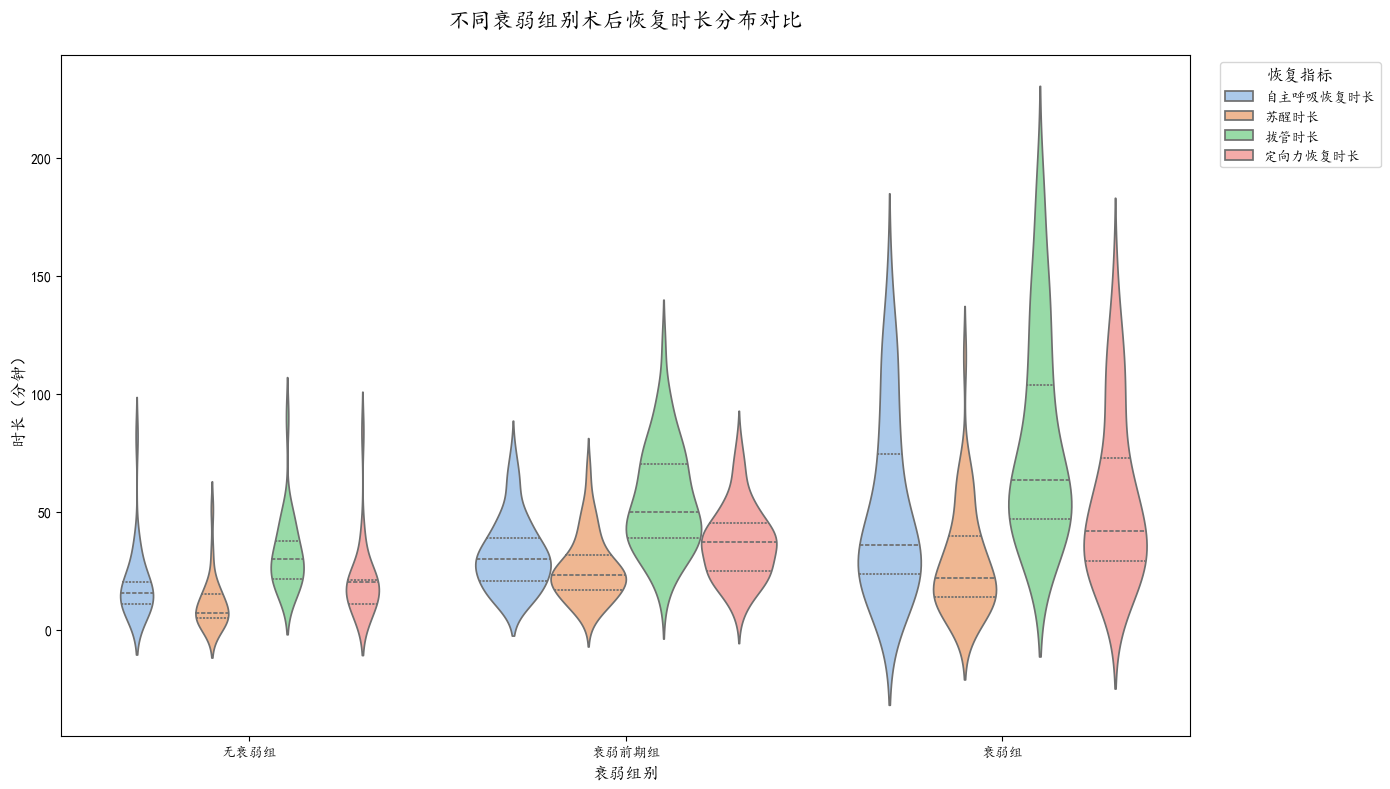

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv('复苏时长.csv', encoding='utf-8')

# 创建衰弱分组（0分：无衰弱组，1-2分：衰弱前期组，3-4分：衰弱组）
bins = [0, 1, 3, 5]
labels = ['无衰弱组', '衰弱前期组', '衰弱组']
df['衰弱组别'] = pd.cut(df['衰弱评分'], 
                       bins=bins, 
                       labels=labels,
                       right=False,
                       include_lowest=True)

# 数据重塑为长格式
melted_df = df.melt(
    id_vars=['衰弱组别'],
    value_vars=['自主呼吸恢复时长', '苏醒时长', '拔管时长', '定向力恢复时长'],
    var_name='恢复指标',
    value_name='时长'
)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制小提琴图（修复警告）
plt.figure(figsize=(14, 8))
sns.violinplot(
    x='衰弱组别',        # 横坐标为衰弱组别
    y='时长',            # 纵坐标为时长
    hue='恢复指标',      # 用颜色区分不同恢复指标
    data=melted_df,
    split=False,         # 不拆分小提琴图
    inner='quartile',    # 显示四分位数线
    palette='pastel',    # 使用柔和配色
    density_norm='count',
    # cut=0
)

# 添加标题和标签
plt.title('不同衰弱组别术后恢复时长分布对比', fontsize=16, pad=20)
plt.xlabel('衰弱组别', fontsize=12)
plt.ylabel('时长（分钟）', fontsize=12)

# 调整图例位置
plt.legend(
    title='恢复指标',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title_fontsize=12
)

# 优化布局
plt.tight_layout()
plt.savefig('使用柔和配色.png', dpi=400, bbox_inches='tight')
plt.show()